# Ejercicio: Predicción de Costes de Seguros Médicos (Insurance Dataset)

En este notebook trabajaremos con un dataset real de seguros médicos. El objetivo es predecir los gastos médicos de un paciente (`charges`) basándonos en sus características demográficas y hábitos de salud.

## Información del Dataset

El dataset contiene las siguientes variables:

| Variable | Tipo | Descripción |
| :--- | :--- | :--- |
| **age** | Numérica | Edad del beneficiario principal. |
| **sex** | Categórica | Género del contratante (male / female). |
| **bmi** | Numérica | Índice de masa corporal ($kg/m^2$). |
| **children** | Numérica | Número de hijos/dependientes cubiertos por el seguro. |
| **smoker** | Categórica | Indica si el beneficiario fuma (yes / no). |
| **region** | Categórica | Zona residencial en EE. UU. (northeast, southeast, southwest, northwest). |
| **charges** (Target) | Numérica | Gastos médicos individuales facturados por el seguro. |

---

# 1. Carga de Datos y Exploración Inicial

Primero, cargamos el dataset directamente desde el archivo y visualizamos su estructura.

In [3]:
import pandas as pd
import numpy as np

# Carga del dataset desde URL
df = pd.read_csv('insurance.csv')

# Mostramos una porción y el tamaño del dataset
print("Dimensiones del dataset:", df.shape)
display(df.head())

# Información sobre tipos de datos y nulos
print("\n-- Nulos y tipos --")
df.info()

Dimensiones del dataset: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



-- Nulos y tipos --
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


# 2. Transformación de variables categóricas

Los modelos que hemos estudiado hasta ahora (**OLS**, **SGD**, **Lasso**, **Ridge**) son modelos matemáticos basados en álgebra lineal. Funcionan calculando distancias, pendientes y productos matriciales.

> **Regla de oro:** Un modelo de regresión lineal solo entiende de números. No sabe qué significa "femenino" o "fumador", por lo que debemos traducir esas palabras a valores numéricos.

### ¿Existen modelos que trabajen con variables categóricas directamente?
Sí, existen modelos basados en **Árboles de Decisión** (como *Random Forest* o *Gradient Boosting*) y otras librerías que pueden gestionar variables de texto de forma nativa. Sin embargo, internamente, incluso estos modelos suelen realizar una conversión automática para poder operar.

Pero por ahora, necesitamos transformar las variables categóricas a numéricas.


## Estrategias de codificación (Encoding)

Para transformar nuestras variables de texto a números, utilizaremos dos estrategias principales dependiendo de cuántas categorías tenga la variable:

### A. Label Encoding (Codificación Binaria)
Se usa cuando la variable tiene solo **dos opciones** (binaria).
* **Ejemplo:** `smoker` (yes/no) o `sex` (male/female).
* **Resultado:** Se asigna un `0` a una categoría y un `1` a la otra. 
* **Ventaja:** No aumenta el número de columnas del dataset.

### B. One-Hot Encoding (Variables Dummy)
Se usa cuando la variable tiene **tres o más opciones** sin un orden jerárquico.
* **Ejemplo:** `region` (northeast, southeast, southwest, northwest).
* **Problema:** Si asignamos números 1, 2, 3 y 4, el modelo pensará que "northwest (4)" vale cuatro veces más que "northeast (1)", lo cual es un error conceptual.
* **Solución:** Creamos una columna nueva por cada categoría. Cada columna solo contendrá ceros y unos. Esto lo podemos crear con matriz Dummy de Pandas, pero surgen 2 problemas a tener en cuenta.
  
    1. **Redundancia:** Si tenemos dos columnas, `Fumador_Sí` y `Fumador_No`, la segunda no aporta información nueva. Si el valor en la primera es **0**, sabemos con 100% de certeza que en la segunda será **1**. 

    2. **Multicolinealidad de variables** Los modelos lineales fallan cuando una variable es una combinación perfecta de otras. Si dejas todas las columnas del Dummy, una columna está correlacionada con las otras 3. Esto genera coeficientes inestables y estimaciones poco fiables. 
     
   > **En conclusión:** Con $n-1$ columnas representas el 100% de la información sin redundancias y sin provocar errores en el modelo.

In [4]:
# Copiamos el dataframe para no tocar el original
df_encoded = df.copy()

# 1. Aplicamos Label Encoding usando .map() de Pandas (o replace) y un dict
df_encoded['smoker'] = df_encoded['smoker'].map({'no': 0, 'yes': 1})
df_encoded['sex'] = df_encoded['sex'].map({'female': 0, 'male': 1})


# 2. Aplicamos One-Hot Encoding a la variable 'region' con get_dummies
# drop_first=True elimina una de las columnas creadas para evitar la redundancia matemática
# dtype=int para que no salga True/False
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True, dtype=int)

df_encoded.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


---
# 3. Separación de Variables (X e y)

Antes de realizar cualquier transformación, separamos las características (**X**) de nuestra variable objetivo (**y**). 

En este punto, convertiremos los datos a **arrays de Numpy**, que es el formato estándar para trabajar con la mayoría de algoritmos de Scikit-Learn.

In [5]:
# Definimos la variable objetivo (Target)
y = df_encoded['charges'].values

# Definimos las características (Features)
# Eliminamos la columna charges de X
X = df_encoded.drop('charges', axis=1).values

print("Tipo de dato de X:", type(X))
print("Forma de X (filas, columnas):", X.shape)
print("\nPrimeras 3 filas de X:")
print(X[:3])

Tipo de dato de X: <class 'numpy.ndarray'>
Forma de X (filas, columnas): (1338, 8)

Primeras 3 filas de X:
[[19.    0.   27.9   0.    1.    0.    0.    1.  ]
 [18.    1.   33.77  1.    0.    0.    1.    0.  ]
 [28.    1.   33.    3.    0.    0.    1.    0.  ]]


### 4. División del Dataset
Para evaluar si nuestro modelo realmente aprende o solo memoriza, dividiremos los datos:
* **Entrenamiento (80%)**: Datos para que el modelo aprenda los pesos.
* **Test (20%)**: Datos "examen" para evaluar el rendimiento final.
* **Nota:** Usa `random_state=42` para garantizar que todos obtengamos los mismos resultados.

In [6]:
# 4. División del Dataset 80/20
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificamos las dimensiones para estar seguros
print(f"Registros totales: {X.shape[0]}")
print(f"Registros de entrenamiento:  {X_train.shape[0]} -> {(X_train.shape[0]*100/X.shape[0]):.2f}%")
print(f"Registros de test:  {X_test.shape[0]} -> {(X_test.shape[0]*100/X.shape[0]):.2f}%")

Registros totales: 1338
Registros de entrenamiento:  1070 -> 79.97%
Registros de test:  268 -> 20.03%


### 5. Escalado de Datos
Los modelos lineales son sensibles a la magnitud de los números. 
1. Aplica un escalador (ej. **RobustScaler**) a los conjuntos de entrenamiento y test.
2. **Visualización:** Genera histogramas de las variables tras el escalado. ¿Qué ha cambiado en los ejes X?


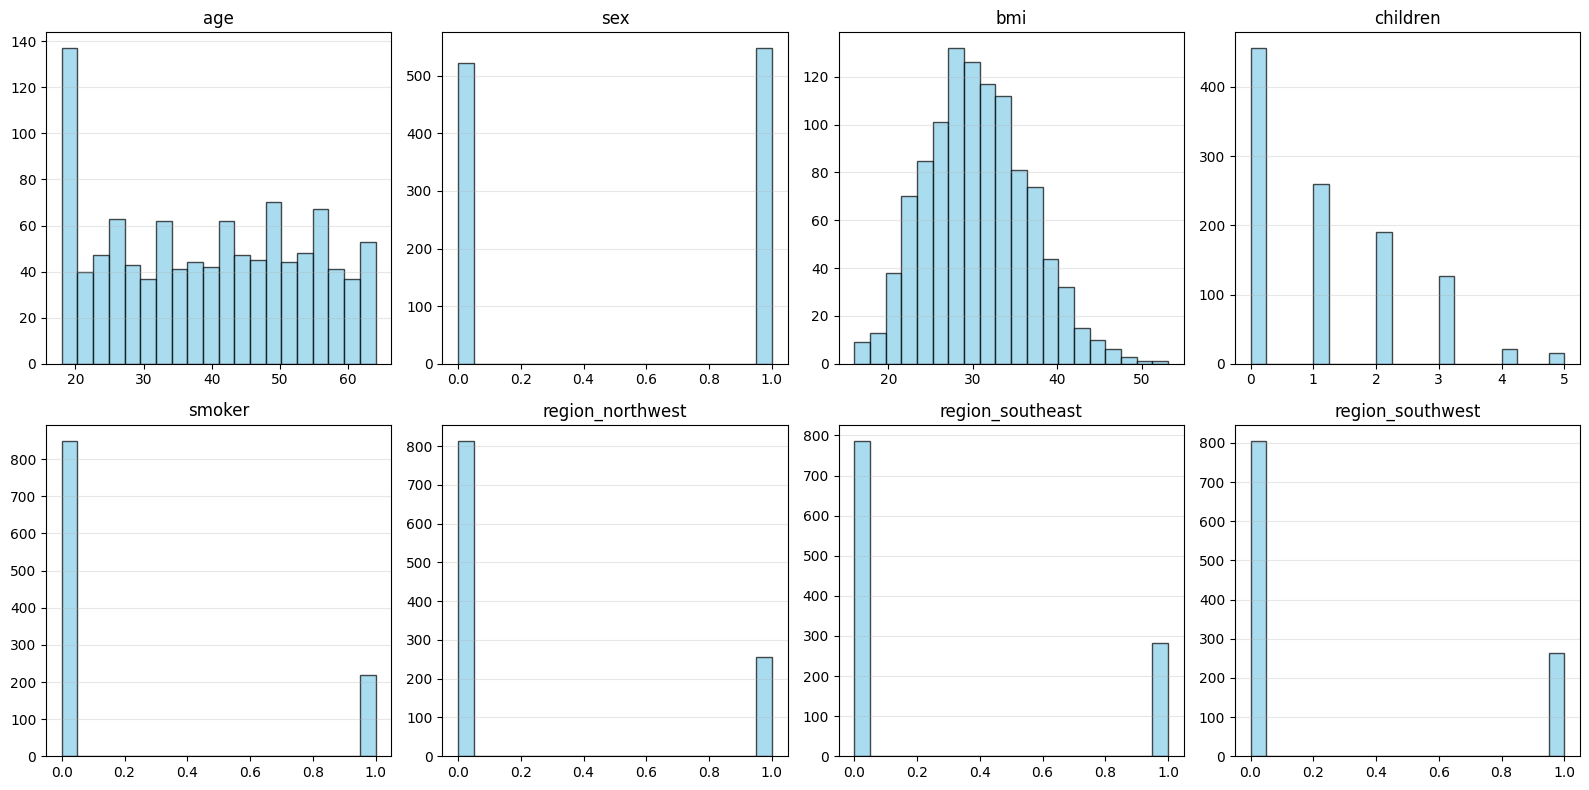

In [7]:
# Visualización de histogramas previo al escalado
import matplotlib.pyplot as plt

# Lista de nombres de columnas según el orden de tu dataset
columns = ['age', 'sex', 'bmi', 'children', 'smoker', 
    'region_northwest', 'region_southeast', 'region_southwest']

# Configuramos la figura
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
axes = axes.flatten() # Aplanamos para iterar fácilmente

for i in range(len(columns)):
    # Graficamos el histograma en el subset correspondiente
    axes[i].hist(X_train[:, i], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    
    # Personalización de cada subgráfico
    axes[i].set_title(columns[i])
    axes[i].grid(axis='y', alpha=0.3)

# Ajustamos para que no se encimen los títulos
plt.tight_layout()
plt.show()

El escalado de datos no es solo un paso de limpieza, sino una optimización fundamental para el algoritmo de Regresión Lineal por varias razones:

1. **Nivelación de Magnitudes:** En el dataset tenemos variables con rangos muy dispares: la edad (18-64), el BMI (15-53) y variables binarias como fumador (0-1).

    Sin escalado: El modelo tiende a ser "tiranizado" por las variables con números más grandes, asignándoles importancia simplemente por su escala y no por su relación real con los gastos médicos.

    Con escalado: Todas las características operan en un rango similar, permitiendo que el modelo detecte patrones basados en la varianza y no en el tamaño de la unidad.

2. **Optimización del Gradiente:** Aunque el método de Mínimos Cuadrados (OLS) es analítico (una fórmula exacta que se calcula en un paso), el Descenso del Gradiente depende de la geometría del error.

    Sin escalar: El algoritmo oscila y tarda más en converger.

    Con escalado: Permite que el algoritmo encuentre los pesos óptimos de forma más rápida y estable.

3. **Interpretabilidad de Coeficientes:** Una vez que el modelo está entrenado, el escalado nos permite comparar los coeficientes directamente:

    Si los datos están escalados, el coeficiente de cada variable refleja su impacto relativo real. Por ejemplo, si el coeficiente de smoker es mayor que el de age tras el escalado, podemos afirmar con rigor que el tabaquismo tiene un peso superior en el aumento de la prima, algo que no podríamos asegurar si cada variable conservara su unidad original (años vs. binario).

4. **Robustez ante Outliers:**

    Al utilizar RobustScaler, hemos asegurado que los valores extremos (especialmente presentes en el IMC) no deformen el entrenamiento. Este escalador utiliza la mediana y el rango intercuartílico, evitando que los outliers sesguen la posición de la recta de regresión, garantizando así un modelo con mayor capacidad de generalización.

**RobutsScaler.** Cada valor se convierte calculando lo siguiente:

    Se resta la Mediana.    
    Se divide por el IQR (Rango entre el percentil 25 y 75).
    Esto garantiza que el 50% central de los datos quede siempre en un rango muy similar, independientemente de lo lejos que estén los outliers.

In [8]:
# Aplicamos
from sklearn.preprocessing import RobustScaler

# Instanciamos el escalador
scaler = RobustScaler()

# AJUSTAMOS y TRANSFORMAMOS los datos de entrenamiento
# Nota: "fit" solo se hace en train para no "contaminar" con info de test
X_train_scaled = scaler.fit_transform(X_train)

# Solo TRANSFORMAMOS los datos de test
X_test_scaled = scaler.transform(X_test)

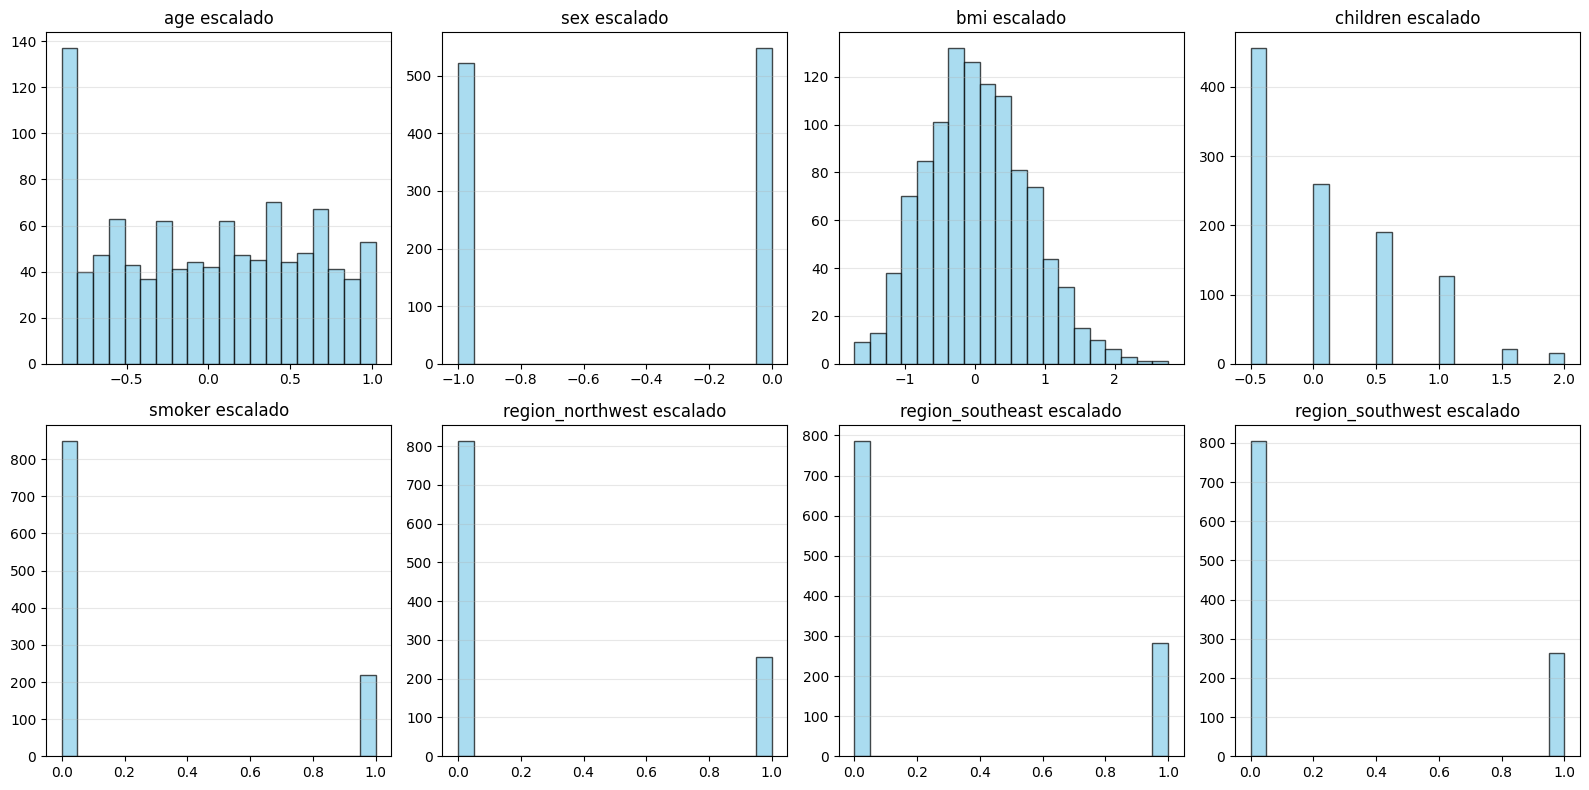

In [9]:
# Visualizamos de nuevo los histogramas
# Visualización de histogramas previo al escalado
import matplotlib.pyplot as plt

# Lista de nombres de columnas según el orden de tu dataset
columns = ['age', 'sex', 'bmi', 'children', 'smoker', 
    'region_northwest', 'region_southeast', 'region_southwest']

# Configuramos la figura
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
axes = axes.flatten() # Aplanamos para iterar fácilmente

for i in range(len(columns)):
    # Graficamos el histograma en el subset correspondiente
    axes[i].hist(X_train_scaled[:, i], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    
    # Personalización de cada subgráfico
    axes[i].set_title(f"{columns[i]} escalado")
    axes[i].grid(axis='y', alpha=0.3)

# Ajustamos para que no se encimen los títulos
plt.tight_layout()
plt.show()

### 6. Entrenamiento de Modelos (La Gran Comparativa)

Realiza el entrenamiento de cada modelo en celdas separadas. Tu misión es **ajustar los hiperparámetros** de cada algoritmo:

* **A. Regresión Lineal Clásica (OLS):** Úsalo como tu "Línea Base" (Base Model). Es el modelo más sencillo y no requiere ajuste de hiperparámetros.
* **B. Descenso de Gradiente Estocástico (SGDRegressor):** Este modelo es sensible. Prueba a variar la tasa de aprendizaje (`eta0`) y el tipo de `learning_rate`. 
    * *¿Consigues que converja sin que los errores se disparen al infinito?*
* **C. Regularización Lasso:** Experimenta con **3 valores distintos de `alpha`** (ej. 0.01, 0.1, 1).
    * Por cada valor, comprueba cuántos coeficientes han sido eliminados (reducidos a cero). ¿Qué variables considera Lasso que no aportan valor?
* **D. Regularización Ridge:** A diferencia de Lasso, Ridge no elimina variables, sino que distribuye el error entre todas ellas "encogiendo" sus coeficientes. Prueba con valores de `alpha` pequeños y grandes. 
    * ¿Cómo se comparan sus coeficientes con los de la Regresión Lineal clásica?
* **E. ElasticNet (híbrido):** Este modelo combina lo mejor de ambos mundos (Lasso y Ridge). Es ideal cuando tenemos muchas variables correlacionadas entre sí.
    * **Hiperparámetros clave:**
        * `alpha`: Controla la fuerza global de la penalización.
        * `l1_ratio`: Si es 1.0, se comporta como Lasso; si es 0.0, como Ridge. 
    * **Experimento:** Prueba un `l1_ratio=0.5` para ver cómo equilibra la selección de variables con la estabilidad.

    La ecuación de la recta será y=w0​+w1​(age)+w2​(bmi)+w3​(smoker)+…

In [10]:
# OLS (mínimos cuadrados ordinarios). 
# Método analítico que minimiza la distancia media de cada punto en el espacio a la recta
from sklearn.linear_model import LinearRegression

ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

print(f"w0: {ols_model.intercept_}")
# Los coeficientes nos dirán el peso de cada variable escalada
print(f"w: {ols_model.coef_}")

# Coeficiente y variables
print(f"\nCoeficientes y variables:\n")
columns = ['age', 'sex', 'bmi', 'children', 'smoker', 
    'region_northwest', 'region_southeast', 'region_southwest']
for i in range(len(columns)):
    print(f"{ols_model.coef_[i]} * {columns[i]}")

w0: 8809.574416261381
w: [ 6.16741694e+03 -1.85916916e+01  2.79491862e+03  8.50557567e+02
  2.36511289e+04 -3.70677326e+02 -6.57864297e+02 -8.09799354e+02]

Coeficientes y variables:

6167.41693994866 * age
-18.59169164101513 * sex
2794.9186213453236 * bmi
850.5575670485505 * children
23651.128855761264 * smoker
-370.67732622780386 * region_northwest
-657.8642965646429 * region_southeast
-809.7993541824678 * region_southwest


El intercept o sesgo es el coste del seguro si todas las variables valen 0.

El resto de coeficientes se interpretan según su valor y signo:

* Valores más cerca del 0: El aporte de esa variable al coste final del seguro es bajo.
* Valores más lejos del 0: El aporte de esa variable al coste final del seguro es alto.
* Coeficiente positivo -> cuanto más alta es la variable, más alto es el coste del seguro.
* Coeficiente negativo -> cuanto más alta es la variable, más bajo es el coste del seguro.

In [11]:
# DESCENSO DEL GRADIENTE
from sklearn.linear_model import SGDRegressor

# Descenso del gradiente es un modelo iterativo que va dando pequeños pasos en dirección al punto óptimo
"""
- eta: Valor interno del algoritmo que define el tamaño del paso en cada iteracción.

- eta0: Es el valor inicial de 'eta' con el que el modelo empieza a ajustar sus pesos en la primera iteración.
        Si es muy alto, el error del modelo crecerá hasta el infinito.
        Si es muy bajo, necesitará millones de pasos (iteraciones) para finalizar.
        
- learning_rate: Indica como se actualiza el eta.

Otros parámetros:
- loss: La función de coste que el algoritmo debe maximizar o minimizar. Por defecto es MSE igual que en OLS (residuos al cuadrado). Cuando más bajo, mejor.
- penalty: Tipo de regularización a aplicar (L1, L2)
- tol: Parámetro de parada. Si la ganancia de varias iteraciones seguidas es menor a tol, el algoritmo para.
- verbose: para ver como se calcula el algoritmo paso a paso. El dato más importante es Avg. loss, que debe ir decreciendo.

¿Consigues que converja sin que los errores se disparen al infinito?
Debemos ver en la salida que Avg. loss va decreciendo. Al principio con saltos más grandes y posteriormente con menos ganancia hasta que para. 
"""

sgd_model = SGDRegressor(max_iter=100, eta0=0.01, random_state=42, verbose=1)
sgd_model.fit(X_train_scaled, y_train)

print(f"Iteraciones realizadas: {sgd_model.n_iter_}")

-- Epoch 1
Norm: 10474.28, NNZs: 8, Bias: 8430.653050, T: 1070, Avg. loss: 57780915.667134, Objective: 57784010.206850
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 13890.06, NNZs: 8, Bias: 8753.664650, T: 2140, Avg. loss: 33996719.221822, Objective: 34004381.076347
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 16185.80, NNZs: 8, Bias: 8749.965573, T: 3210, Avg. loss: 27610886.255849, Objective: 27622268.969983
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 17847.24, NNZs: 8, Bias: 8719.173738, T: 4280, Avg. loss: 24293871.937402, Objective: 24308413.096513
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 19118.57, NNZs: 8, Bias: 8702.347319, T: 5350, Avg. loss: 22379338.581899, Objective: 22396406.531253
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 20084.35, NNZs: 8, Bias: 8635.891058, T: 6420, Avg. loss: 21203286.293251, Objective: 21222532.916942
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 20850.76, NNZs: 8, Bias: 8578.472457, T: 7490, Avg. loss: 2

In [13]:
# REGULARIZACIÓN L1: LASSO 
# si una variable no ayuda mucho, el coeficiente w correspondiente a esa variable valdrá 0, lo que elimina a la variable del modelo.
from sklearn.linear_model import Lasso

columns = ['age', 'sex', 'bmi', 'children', 'smoker', 
    'region_northwest', 'region_southeast', 'region_southwest']
print(f"Columnas: {columns}")

# El hiperparámetro alpha indica la cantidad de regularización
# Cuanto más alto, más coeficientes pondrá a 0
alphas = [0.01, 10, 100] 
for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train_scaled, y_train)
    # Contamos cuántos coeficientes son CERO
    eliminados = sum(lasso_model.coef_ == 0)
    print(f"\nAlpha {a}: Variables eliminadas: {eliminados} de {len(columns)}")
    print(f"Coeficientes {lasso_model.coef_}")

Columnas: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']

Alpha 0.01: Variables eliminadas: 0 de 8
Coeficientes [ 6.16739015e+03 -1.85459647e+01  2.79488476e+03  8.50531502e+02
  2.36510633e+04 -3.70512892e+02 -6.57686697e+02 -8.09630986e+02]

Alpha 10: Variables eliminadas: 1 de 8
Coeficientes [ 6140.44063616    -0.          2761.40954573   824.83721181
 23588.00042517  -205.39026071  -480.41580845  -641.57455848]

Alpha 100: Variables eliminadas: 4 de 8
Coeficientes [ 5896.07480393     0.          2550.95415238   604.57869452
 23024.54822414     0.            -0.            -0.        ]


In [14]:
# REGULARIZACIÓN L2: Ridge
# no elimina coeficientes, evita que algunas variables dominen el modelo con coeficientes extremadamente grandes.
from sklearn.linear_model import Ridge

# El hiperparámetro alpha indica la cantidad de regularización
# Cuanto más alto, más cerca del 0 estarán los coeficientes.
alphas = [0.1, 100, 1000] 
for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train_scaled, y_train)
    print(f"Coeficientes Ridge: {ridge_model.coef_}\n")
    # Verás que los de Ridge son "más bajitos" (están más cerca de cero a medida que aumentamos alpha)

# Compara estos coeficientes con ols_model.coef_
print(f"Coeficientes OLS: {ols_model.coef_}")

Coeficientes Ridge: [ 6.16532695e+03 -1.77900963e+01  2.79438382e+03  8.50597482e+02
  2.36373271e+04 -3.70173669e+02 -6.56291051e+02 -8.09030327e+02]

Coeficientes Ridge: [ 4652.89007972   350.95244152  2400.82299391   816.23100398
 14934.83404225  -221.80920906    27.850466    -491.34549163]

Coeficientes Ridge: [1537.1840242   242.76447767 1114.34293134  370.40857693 3460.66370965
 -108.17502417  203.50362365 -147.55316298]

Coeficientes OLS: [ 6.16741694e+03 -1.85916916e+01  2.79491862e+03  8.50557567e+02
  2.36511289e+04 -3.70677326e+02 -6.57864297e+02 -8.09799354e+02]


In [15]:
# ELASTICNET (HÍBRIDO L1 Y L2)
from sklearn.linear_model import ElasticNet

# l1_ratio=0.5 significa 50% Lasso (L1) y 50% Ridge
en_model = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
en_model.fit(X_train_scaled, y_train)

print(f"Coeficientes ElasticNet: {en_model.coef_}")

Coeficientes ElasticNet: [ 5240.37398134   253.90331491  2559.686423     844.48601506
 18022.50338614  -249.46999518  -155.80422941  -579.92915366]


In [17]:
# Comparativas de coeficientes
import pandas as pd
coef_comparativa = pd.DataFrame({
    'Variable': columns,
    'OLS': ols_model.coef_,
    'Lasso (a=100)': lasso_model.coef_, # El último lasso del for
    'Ridge (a=1000)': ridge_model.coef_, # El último ridge del for
    'ElasticNet 0.5, a=0.1': en_model.coef_
})
coef_comparativa

,Variable,OLS,Lasso (a=100),Ridge (a=1000),"ElasticNet 0.5, a=0.1"
0,age,6167.416940,5896.074804,1537.184024,5240.373981
1,sex,-18.591692,0.000000,242.764478,253.903315
2,bmi,2794.918621,2550.954152,1114.342931,2559.686423
3,children,850.557567,604.578695,370.408577,844.486015
4,smoker,23651.128856,23024.548224,3460.663710,18022.503386
5,region_northwest,-370.677326,0.000000,-108.175024,-249.469995
6,region_southeast,-657.864297,-0.000000,203.503624,-155.804229
7,region_southwest,-809.799354,-0.000000,-147.553163,-579.929154


### 7. Resumen y comparación del Rendimiento
Para cada uno de tus mejores intentos en los modelos anteriores, calcula en el conjunto de **Test**:
1.  **R² Ajustado:** Cuanto más alto, mejor, R2=0 el modelo es igual que simplemente calcular la media. R2=1 el modelo es perfecto.
2.  **MAE (Error Absoluto Medio):** Del conjunto de test, cogemos los residuos en valor absoluto (valor real - valor predicho) y calculamos la media. Cuanto más bajo, mejor
3.  **RMSE (Raíz del Error Cuadrático Medio):** ¿Primero elevas los errores al cuadrado, haces el promedio y, al final, sacas la raíz cuadrada para volver a las unidades originales (dólares). Así se penalizan más los errores más grandes que los pequeños. Cuanto más bajo, mejor



In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    
    # Métricas Base
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # R² Ajustado
    # n = número de muestras, p = número de predictores
    n = len(y_test)
    p = X_test.shape[1]
    r2_ajustado = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    return {
        "Modelo": nombre,
        "MAE ($)": round(mae, 2),
        "RMSE ($)": round(rmse, 2),
        "R2 Ajustado": round(r2_ajustado, 4)
    }

# Ejemplo de uso con tus modelos entrenados
resultados = []
resultados.append(evaluar_modelo("OLS", ols_model, X_test_scaled, y_test))
resultados.append(evaluar_modelo("SGD", sgd_model, X_test_scaled, y_test))
resultados.append(evaluar_modelo("Ridge", ridge_model, X_test_scaled, y_test))
resultados.append(evaluar_modelo("Lasso", lasso_model, X_test_scaled, y_test))
resultados.append(evaluar_modelo("ElasticNET", en_model, X_test_scaled, y_test))
# ... añade los demás

df_resultados = pd.DataFrame(resultados)
df_resultados

,Modelo,MAE ($),RMSE ($),R2 Ajustado
0,OLS,4181.19,5796.28,0.7769
1,SGD,4200.91,5802.35,0.7764
2,Ridge,8405.29,10861.35,0.2167
3,Lasso,4245.83,5860.02,0.7720
4,ElasticNET,4818.67,6400.80,0.7279


### 8. Persistencia
* Guarda el **mejor modelo** y el **escalador** en archivos `.pkl` utilizando la librería `joblib`.
* ¡Felicidades! Tu modelo está listo para ser integrado en una aplicación real.

In [ ]:
import joblib

# 1. Guardamos el mejor modelo Lasso
# Asumiendo que 'lasso_model' es tu modelo final tras ajustar el alpha
joblib.dump(sgd_model, 'mejor_modelo_lasso.pkl')

# 2. Guardamos el escalador
# Es vital guardar el escalador para que los datos nuevos 
# tengan el mismo procesamiento que los de entrenamiento
joblib.dump(scaler, 'escalador_datos.pkl')

print("¡Archivos persistidos correctamente!")
